# Assignment 2 — Part B: Suvidha Micro-Finance

In [ ]:
# Setup — imports and raw-file locations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from dateutil import parser
from pathlib import Path

# Locate the raw CSV files. Keep them in the same working folder as the notebook.
def find_file(key):
    matches = list(Path('.').glob(f'*{key}*.csv')) + list(Path('/mnt/data').glob(f'*{key}*.csv'))
    if not matches:
        raise FileNotFoundError(f'Could not find CSV containing: {key}')
    return str(matches[0])

MERIDIAN_FILE = find_file('meridian_daily_sales_raw')
SUVIDHA_FILE = find_file('suvidha_loan_predictions_raw')
print('Meridian:', MERIDIAN_FILE)
print('Suvidha :', SUVIDHA_FILE)


## Part B — Q1. Load file; report shape, dtypes, and missing counts

In [27]:
# Q1 — Code
loan_raw=pd.read_csv(SUVIDHA_FILE)
print('Shape:', loan_raw.shape)
print(); print('Dtypes:'); print(loan_raw.dtypes)
print(); print('Missing counts:'); print(loan_raw.isna().sum())

Shape: (2400, 9)

Dtypes:
loan_id            object
loan_amount        object
tenure_months       int64
interest_rate     float64
borrower_age       object
monthly_income     object
actual_default     object
model_flag         object
risk_score        float64
dtype: object

Missing counts:
loan_id            0
loan_amount        0
tenure_months      0
interest_rate      0
borrower_age      38
monthly_income    36
actual_default    40
model_flag        22
risk_score         0
dtype: int64


**Q1 — Interpretation:** The raw pilot contains **2,400 loans and 9 columns**. There are **40 missing actual outcomes**, **22 missing model flags**, **38 missing borrower ages**, and **36 missing monthly-income cells** before considering sentinel/text missing values.

## Part B — Q2. Clean loan_amount to numeric

In [28]:
# Q2 — Code
loan=loan_raw.copy()
loan['loan_amount']=pd.to_numeric(loan['loan_amount'].astype(str).str.replace(r'Rs\s*','',regex=True).str.replace(',','',regex=False), errors='coerce')
print('loan_amount dtype:', loan['loan_amount'].dtype)
print('Missing after conversion:', loan['loan_amount'].isna().sum())
print(loan['loan_amount'].head(12))

loan_amount dtype: float64
Missing after conversion: 0
0      60777.81992
1     258399.89230
2     114338.03220
3      60919.14875
4     104225.15810
5     116603.65300
6      87640.16155
7      67409.44300
8      87587.32314
9      66426.97342
10    177953.00000
11     83585.00000
Name: loan_amount, dtype: float64


**Q2 — Interpretation:** All loan amounts convert successfully to numeric values, including entries originally stored with `Rs` and commas.

## Part B — Q3. Standardize actual_default and model_flag to boolean

In [29]:
# Q3 — Code
print('actual_default raw:', sorted(loan_raw['actual_default'].dropna().astype(str).unique()))
print('model_flag raw    :', sorted(loan_raw['model_flag'].dropna().astype(str).unique()))
flag_map={'yes':True,'y':True,'1':True,'true':True,'no':False,'n':False,'0':False,'false':False}
def clean_bool(s):
    return s.astype(str).str.strip().str.lower().replace('nan',np.nan).map(flag_map)
loan['actual_default']=clean_bool(loan['actual_default'])
loan['model_flag']=clean_bool(loan['model_flag'])
print(); print('Clean actual:', loan['actual_default'].value_counts(dropna=False))
print('Clean model :', loan['model_flag'].value_counts(dropna=False))

actual_default raw: ['0', '1', 'FALSE', 'N', 'No', 'TRUE', 'Y', 'Yes']
model_flag raw    : ['0', '1', 'FALSE', 'N', 'No', 'TRUE', 'Y', 'Yes']

Clean actual: actual_default
False    2161
True      199
NaN        40
Name: count, dtype: int64
Clean model : model_flag
False    2222
True      156
NaN        22
Name: count, dtype: int64


**Q3 — Interpretation:** All documented Yes/No families are mapped consistently. Blank outcomes/flags remain missing rather than being turned into either class.

## Part B — Q4. Drop rows missing actual_default or model_flag

In [30]:
# Q4 — Code
before=len(loan)
valid=loan.dropna(subset=['actual_default','model_flag']).copy()
print('Rows before:', before)
print('Rows after :', len(valid))
print('Rows dropped:', before-len(valid))

Rows before: 2400
Rows after : 2339
Rows dropped: 61


**Q4 — Interpretation:** **61 rows are excluded**, leaving **2,339 evaluable loans**. Dropping is correct because imputing an open loan’s future default or inventing a model prediction would contaminate the confusion matrix with fabricated labels.

## Part B — Q5. Clean monthly_income and justify missing treatment

In [31]:
# Q5 — Code
loan['income_not_disclosed']=loan['monthly_income'].astype(str).str.strip().str.lower().eq('not disclosed')
loan['income_sentinel_minus1']=loan['monthly_income'].astype(str).str.strip().eq('-1')
loan['monthly_income']=pd.to_numeric(loan['monthly_income'], errors='coerce')
loan.loc[loan['monthly_income'].eq(-1),'monthly_income']=np.nan
# Apply same cleaning to valid evaluation set
valid=loan.dropna(subset=['actual_default','model_flag']).copy()
print('Not disclosed count:', loan['income_not_disclosed'].sum())
print('-1 sentinel count    :', loan['income_sentinel_minus1'].sum())
print('Final missing income:', loan['monthly_income'].isna().sum())

Not disclosed count: 31
-1 sentinel count    : 29
Final missing income: 96


**Q5 — Interpretation:** Both `-1` and `not disclosed` are converted to `NaN` because neither is a valid income, but separate indicators preserve their different meanings: one is a system sentinel and the other is borrower non-disclosure.

## Part B — Q6. Build the 2×2 confusion matrix

In [32]:
# Q6 — Code
y=valid['actual_default'].astype(bool); pred=valid['model_flag'].astype(bool)
tn,fp,fn,tp=confusion_matrix(y,pred,labels=[False,True]).ravel()
cm_table=pd.DataFrame([[tn,fp],[fn,tp]], index=['Actual No Default','Actual Default'], columns=['Predicted No Default','Predicted Default'])
print(cm_table)
print(); print(f'TN={tn}: safe loan correctly left unflagged')
print(f'FP={fp}: safe loan incorrectly flagged, causing an unnecessary call')
print(f'FN={fn}: actual default missed, the costly failure for Suvidha')
print(f'TP={tp}: actual default correctly flagged for early intervention')

                   Predicted No Default  Predicted Default
Actual No Default                  2122                 20
Actual Default                       64                133

TN=2122: safe loan correctly left unflagged
FP=20: safe loan incorrectly flagged, causing an unnecessary call
FN=64: actual default missed, the costly failure for Suvidha
TP=133: actual default correctly flagged for early intervention


**Q6 — Interpretation:** The model produces **TN=2,122, FP=20, FN=64, TP=133**. The 64 false negatives are especially important because the business states that missed defaults cost much more than unnecessary calls.

## Part B — Q7. Compute accuracy and explain why it can mislead

In [33]:
# Q7 — Code
accuracy=accuracy_score(y,pred); base_rate=y.mean()
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Actual default rate: {base_rate:.4f} ({base_rate*100:.2f}%)')
print(f'No-default baseline accuracy: {(1-base_rate)*100:.2f}%')

Accuracy: 0.9641 (96.41%)
Actual default rate: 0.0842 (8.42%)
No-default baseline accuracy: 91.58%


**Q7 — Interpretation:** Accuracy is **96.41%**, but defaults are only **8.42%** of the evaluable sample, so a trivial all-safe model would already score about **91.58%** accuracy. Accuracy therefore hides whether the model actually catches costly defaults.

## Part B — Q8. Compute precision

In [34]:
# Q8 — Code
precision=precision_score(y,pred)
print(f'Precision: {precision:.4f} ({precision*100:.2f}%)')

Precision: 0.8693 (86.93%)


**Q8 — Interpretation:** Precision is **86.93%**. For a collections officer, this means roughly 87 of every 100 model-flagged loans are genuine 90-day defaults in this pilot sample, so most calls are directed at real risk.

## Part B — Q9. Compute recall (sensitivity)


In [35]:
# Q9 — Code
recall=recall_score(y,pred)
print(f'Recall: {recall:.4f} ({recall*100:.2f}%)')

Recall: 0.6751 (67.51%)


**Q9 — Interpretation:** Recall is **67.51%**. The model catches about two-thirds of actual defaults but misses **64 of 197**, which is material given the stated high cost of false negatives.

## Part B — Q10. Compute specificity

In [36]:
# Q10 — Code
specificity=tn/(tn+fp)
print(f'Specificity: {specificity:.4f} ({specificity*100:.2f}%)')

Specificity: 0.9907 (99.07%)


**Q10 — Interpretation:** Specificity is **99.07%**. Only 20 safe borrowers are false alarms under the existing hard flag, so wasted officer time from false positives is currently low.

## Part B — Q11. Compute F1 and discuss optimization

In [37]:
# Q11 — Code
f1=f1_score(y,pred)
print(f'F1-score: {f1:.4f}')

F1-score: 0.7600


**Q11 — Interpretation:** F1 is **0.760**. It is useful as a balanced summary, but it is not the ideal sole objective here because Suvidha explicitly says a missed default costs much more than a wasted call; the rollout decision should therefore give **recall more weight** than ordinary F1 does.

## Part B — Q12. Prefer higher precision or higher recall?


In [38]:
# Q12 — Code
print('False positives:', fp)
print('False negatives:', fn)

False positives: 20
False negatives: 64


**Q12 — Interpretation:** Given **64 FN versus only 20 FP**, and the stated higher cost of missed defaults, Suvidha should prefer **higher recall**, accepting some reduction in precision if the additional false-alarm workload remains operationally manageable.

## Part B — Q13. Recompute at risk_score threshold 0.3

In [39]:
# Q13 — Code
pred03=valid['risk_score']>=0.3
tn03,fp03,fn03,tp03=confusion_matrix(y,pred03,labels=[False,True]).ravel()
prec03=precision_score(y,pred03); rec03=recall_score(y,pred03)
print(pd.DataFrame([[tn03,fp03],[fn03,tp03]], index=['Actual No Default','Actual Default'], columns=['Predicted No Default','Predicted Default']))
print(f'Precision @0.3: {prec03:.4f}')
print(f'Recall @0.3   : {rec03:.4f}')

                   Predicted No Default  Predicted Default
Actual No Default                   664               1478
Actual Default                        0                197
Precision @0.3: 0.1176
Recall @0.3   : 1.0000


**Q13 — Interpretation:** At **0.3**, recall rises to **100% (FN=0)**, but precision collapses to about **11.80%** because **1,472 safe loans** are falsely flagged. This supports the direction of lowering the threshold to protect recall, but **0.3 is operationally too aggressive** unless Suvidha can tolerate a very large call volume.

## Part B — Q14. Plot precision and recall against threshold

 threshold  precision  recall
       0.1     0.0854  1.0000
       0.2     0.0919  1.0000
       0.3     0.1180  1.0000
       0.4     0.2032  0.9695
       0.5     0.4410  0.9289
       0.6     0.8263  0.7005
       0.7     0.9744  0.3858
       0.8     1.0000  0.1320
       0.9     1.0000  0.0152


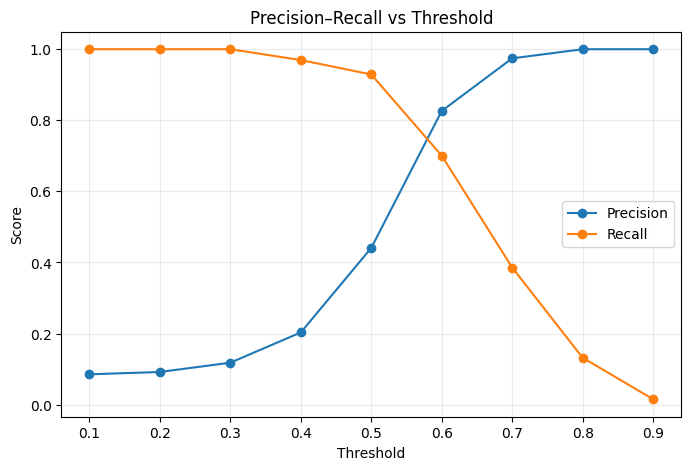

Closest sampled crossing: {'threshold': 0.6, 'precision': 0.8263473053892215, 'recall': 0.700507614213198}


In [40]:
# Q14 — Code
threshold_rows=[]
for t in np.arange(.1,1,.1):
    p=valid['risk_score']>=t
    threshold_rows.append([t, precision_score(y,p,zero_division=0), recall_score(y,p,zero_division=0)])
threshold_table=pd.DataFrame(threshold_rows,columns=['threshold','precision','recall'])
print(threshold_table.round(4).to_string(index=False))
plt.figure(figsize=(8,5))
plt.plot(threshold_table['threshold'],threshold_table['precision'],marker='o',label='Precision')
plt.plot(threshold_table['threshold'],threshold_table['recall'],marker='o',label='Recall')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Precision–Recall vs Threshold'); plt.legend(); plt.grid(alpha=.25); plt.show()
closest=threshold_table.iloc[(threshold_table['precision']-threshold_table['recall']).abs().argmin()]
print('Closest sampled crossing:', closest.to_dict())

**Q14 — Interpretation:** Within the required 0.1 steps, precision and recall are closest around **0.6** (precision ≈ **82.63%**, recall ≈ **70.05%**). This is the approximate balance point; thresholds below it favor catching more defaults, while thresholds above it favor fewer false alarms.

## Part B — Q15. State null and alternative hypotheses for loan_amount

In [41]:
# Q15 — Code
print('H0: Mean loan_amount is the same for defaulted and non-defaulted loans.')
print('H1: Mean loan_amount is different for defaulted and non-defaulted loans.')

H0: Mean loan_amount is the same for defaulted and non-defaulted loans.
H1: Mean loan_amount is different for defaulted and non-defaulted loans.


**Q15 — Interpretation:** The hypotheses are correctly two-sided: **H₀: μdefault = μnon-default** versus **H₁: μdefault ≠ μnon-default**.

## Part B — Q16. Compare mean loan_amount by outcome

In [42]:
# Q16 — Code
default_amt=valid.loc[y,'loan_amount'].dropna(); safe_amt=valid.loc[~y,'loan_amount'].dropna()
print(f'Default mean loan amount    : {default_amt.mean():.2f}')
print(f'Non-default mean loan amount: {safe_amt.mean():.2f}')
print(f'Observed difference         : {default_amt.mean()-safe_amt.mean():.2f}')

Default mean loan amount    : 96899.91
Non-default mean loan amount: 92408.81
Observed difference         : 4491.10


**Q16 — Interpretation:** Defaulted loans average about **96,899.91**, compared with **92,408.81** for non-defaulted loans—an apparent difference of about **4,491.10**. A significance test is needed before treating that sample gap as evidence of a population difference.

## Part B — Q17. Run an appropriate two-sample test

In [43]:
# Q17 — Code
loan_test=stats.ttest_ind(default_amt,safe_amt,equal_var=False,nan_policy='omit')
print(f'Welch t-statistic: {loan_test.statistic:.4f}')
print(f'p-value: {loan_test.pvalue:.6f}')

Welch t-statistic: 1.3588
p-value: 0.175574


**Q17 — Interpretation:** The Welch test gives **t ≈ 1.359, p ≈ 0.1756**. The observed difference is not statistically significant at α=0.05.

## Part B — Q18. Decision at α=0.05

In [44]:
# Q18 — Code
alpha=.05
print('Decision:', 'Reject H0' if loan_test.pvalue<alpha else 'Fail to reject H0')

Decision: Fail to reject H0


**Q18 — Interpretation:** Because **p≈0.176 > 0.05**, we **fail to reject H₀**. In branch-manager language: this pilot does not provide strong enough evidence that average loan amount differs between borrowers who defaulted and those who did not.

## Part B — Q19. Explain Type I and Type II errors

In [45]:
# Q19 — Code
print('Type I: conclude loan amount differs by default status when no real population difference exists.')
print('Type II: conclude there is insufficient evidence of a difference when a real population difference actually exists.')

Type I: conclude loan amount differs by default status when no real population difference exists.
Type II: conclude there is insufficient evidence of a difference when a real population difference actually exists.


**Q19 — Interpretation:** A **Type I error** could make Suvidha change lending rules based on a loan-amount effect that is not real, potentially restricting borrowers unnecessarily. A **Type II error** could miss a genuine relationship that would help risk policy. Which is riskier depends on policy costs; because unwarranted lending restrictions can directly affect many customers while missed risk can increase losses, Suvidha should explicitly quantify both costs rather than treating either error as automatically harmless.

## Part B — Q20. Repeat hypothesis test for interest_rate

In [46]:
# Q20 — Code
default_ir=valid.loc[y,'interest_rate'].dropna(); safe_ir=valid.loc[~y,'interest_rate'].dropna()
ir_test=stats.ttest_ind(default_ir,safe_ir,equal_var=False,nan_policy='omit')
print(f'Default mean interest rate    : {default_ir.mean():.4f}')
print(f'Non-default mean interest rate: {safe_ir.mean():.4f}')
print(f'Welch t-statistic: {ir_test.statistic:.4f}')
print(f'p-value: {ir_test.pvalue:.6f}')
print('Decision:', 'Reject H0' if ir_test.pvalue<.05 else 'Fail to reject H0')

Default mean interest rate    : 14.8023
Non-default mean interest rate: 14.4616
Welch t-statistic: 1.5778
p-value: 0.115960
Decision: Fail to reject H0


**Q20 — Interpretation:** Defaulted loans have mean interest rate **14.8023** versus **14.4616** for non-defaulted loans, but **p≈0.1160 > 0.05**. We again fail to reject H₀, so the conclusion does **not** change: this pilot does not show a statistically significant mean difference at the 5% level.

## Part B — Q21. Summarize core model metrics

In [47]:
# Q21 — Code
metrics_table=pd.DataFrame({'Accuracy':[accuracy],'Precision':[precision],'Recall':[recall],'F1':[f1],'Specificity':[specificity]})
print((metrics_table*100).round(2).astype(str)+'%')

  Accuracy Precision  Recall     F1 Specificity
0   96.41%    86.93%  67.51%  76.0%      99.07%


**Q21 — Interpretation:** The hard model flag achieves **96.41% accuracy, 86.93% precision, 67.51% recall, 76.00% F1, and 99.07% specificity**. The main weakness relative to the business objective is recall.

## Part B — Q22. Recommend a risk_score threshold

In [48]:
# Q22 — Code
detail=[]
for t in [0.4,0.5,0.6]:
    p=valid['risk_score']>=t
    tn_t,fp_t,fn_t,tp_t=confusion_matrix(y,p,labels=[False,True]).ravel()
    detail.append([t,precision_score(y,p),recall_score(y,p),fp_t,fn_t])
print(pd.DataFrame(detail,columns=['threshold','precision','recall','FP','FN']).round(4).to_string(index=False))

 threshold  precision  recall  FP  FN
       0.4     0.2032  0.9695 749   6
       0.5     0.4410  0.9289 232  14
       0.6     0.8263  0.7005  29  59


**Q22 — Interpretation:** A practical starting threshold is **0.5**: it raises recall to about **92.89%** and reduces false negatives to **14**, while precision remains about **44.10%** with **232 false positives**. Threshold 0.4 gains only ~4 percentage points more recall but increases false positives to 749; 0.6 has better precision but leaves 59 defaults missed. Because real call capacity/cost data are not provided, 0.5 should be validated operationally rather than treated as a final immutable cutoff.

## Part B — Q23. Name a non-statistical risk of lowering threshold too far

In [49]:
# Q23 — Code
print('Operational risk: alert/officer fatigue from too many false-positive calls.')

Operational risk: alert/officer fatigue from too many false-positive calls.


**Q23 — Interpretation:** If the threshold is too low, officers may face hundreds or thousands of low-value alerts. **Alert fatigue** can reduce attention to truly risky cases, increase workload/cost, and create a poor borrower experience even if recall looks excellent.

## Part B — Q24. Write the risk team’s go/no-go recommendation

In [50]:
# Q24 — Code
recommendation=f"""The pilot model shows useful signal: its current hard flag has {precision*100:.2f}% precision but only {recall*100:.2f}% recall, leaving {fn} actual defaults unflagged. Because missed defaults are more expensive than unnecessary calls, the current operating point should not be rolled out unchanged. A threshold near 0.5 is a stronger pilot candidate, raising recall to about 92.89% while producing 232 false positives in this sample. Suvidha should proceed with a controlled/monitored rollout only if branch staffing can absorb that alert volume and should track default capture, false alarms, and borrower-contact effects. The threshold should be recalibrated after a larger multi-branch sample rather than fixed permanently from this single pilot."""
print(recommendation)

The pilot model shows useful signal: its current hard flag has 86.93% precision but only 67.51% recall, leaving 64 actual defaults unflagged. Because missed defaults are more expensive than unnecessary calls, the current operating point should not be rolled out unchanged. A threshold near 0.5 is a stronger pilot candidate, raising recall to about 92.89% while producing 232 false positives in this sample. Suvidha should proceed with a controlled/monitored rollout only if branch staffing can absorb that alert volume and should track default capture, false alarms, and borrower-contact effects. The threshold should be recalibrated after a larger multi-branch sample rather than fixed permanently from this single pilot.


**Q24 — Interpretation:** The evidence supports a **controlled rollout with threshold recalibration and monitoring**, rather than an unchanged all-branch deployment of the current hard flag. This conclusion is driven by the expensive 64 false negatives at the current operating point and the much stronger recall available around 0.5.

## Part B — Q25. What should a second pilot log add?

In [51]:
# Q25 — Code
print('Recommended addition: a larger, multi-branch sample with a longer outcome window so the log contains more observed defaults.')

Recommended addition: a larger, multi-branch sample with a longer outcome window so the log contains more observed defaults.


**Q25 — Interpretation:** The next pilot should collect a **larger multi-branch sample with a longer observation window**, producing more actual default events. Because defaults are only about 8.4% here, more positive cases would make recall, threshold trade-offs, and group comparisons more stable and more representative of full rollout conditions.

In [52]:
# Q25 — Code
# Save the cleaned Part B evaluation dataset required by the assignment.
CLEAN_SUVIDHA='suvidha_loan_predictions_cleaned.csv'
valid.to_csv(CLEAN_SUVIDHA,index=False)
print('Saved:', CLEAN_SUVIDHA, 'Rows:', len(valid))

Saved: suvidha_loan_predictions_cleaned.csv Rows: 2339
